# 02. K-Means 증상 클러스터링
**비염 유형 분류: 콧물형 / 코막힘형 / 자극민감형**

---
이 노트북에서 수행할 내용:
1. 최적 클러스터 수 탐색 (Elbow + Silhouette)
2. K-Means 학습 및 유형 분류
3. 클러스터 프로파일 시각화
4. 모델 저장

In [17]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'  # 윈도우 한글 폰트
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120
import warnings
warnings.filterwarnings('ignore')

from src.models.clustering import find_optimal_k, train_kmeans, plot_cluster_profiles

print('환경 준비 완료 ✅')

환경 준비 완료 ✅


## 1. 데이터 로드

In [18]:
# 더미 데이터 (실제 전처리 완료 데이터는 아래 주석 해제)
# df = pd.read_csv('../data/processed/merged_data.csv', parse_dates=['date'])

np.random.seed(42)
n = 400

# 3가지 비염 유형 시뮬레이션
group1 = pd.DataFrame({  # 콧물-재채기 우세
    'nasal_discharge': np.random.normal(7, 1.2, n//3),
    'nasal_congestion': np.random.normal(3, 1.5, n//3),
    'sneezing': np.random.normal(7, 1.5, n//3),
    'eye_itching': np.random.normal(4, 1.2, n//3),
})
group2 = pd.DataFrame({  # 코막힘 우세
    'nasal_discharge': np.random.normal(3, 1.5, n//3),
    'nasal_congestion': np.random.normal(8, 1.0, n//3),
    'sneezing': np.random.normal(2, 1.2, n//3),
    'eye_itching': np.random.normal(2, 1.0, n//3),
})
group3 = pd.DataFrame({  # 자극 민감형
    'nasal_discharge': np.random.normal(5, 1.5, n//3),
    'nasal_congestion': np.random.normal(5, 1.5, n//3),
    'sneezing': np.random.normal(5, 1.8, n//3),
    'eye_itching': np.random.normal(7, 1.2, n//3),
})

df = pd.concat([group1, group2, group3], ignore_index=True)
df = df.clip(0, 10).round(1)

print(f'데이터 크기: {df.shape}')
df.head()

데이터 크기: (399, 4)


,nasal_discharge,nasal_congestion,sneezing,eye_itching
0,7.6,3.7,9.4,5.5
1,6.8,1.6,4.9,2.1
2,7.8,5.3,6.3,3.3
3,8.8,1.8,7.2,4.0
4,6.7,2.5,9.2,4.1


## 2. 최적 클러스터 수 탐색

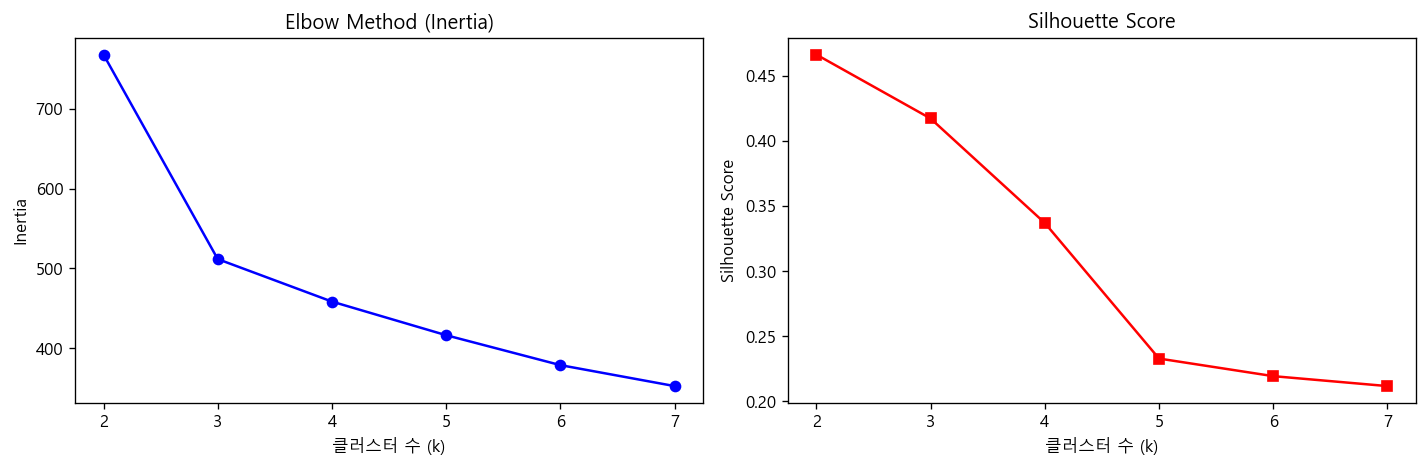


→ 추천 클러스터 수: 2


In [19]:
from sklearn.preprocessing import StandardScaler

VAS_FEATURES = ['nasal_discharge', 'nasal_congestion', 'sneezing', 'eye_itching']
X = StandardScaler().fit_transform(df[VAS_FEATURES])

best_k = find_optimal_k(
    X, 
    k_range=range(2, 8),
    save_path='../outputs/figures/05_elbow_silhouette.png'
)
print(f'\n→ 추천 클러스터 수: {best_k}')

## 3. K-Means 학습 (k=3)

In [20]:
df_clustered, model, scaler = train_kmeans(
    df,
    features=VAS_FEATURES,
    n_clusters=3,
    model_save_path='../outputs/models/kmeans_rhinitis.pkl'
)

print('\n=== 클러스터 분포 ===')
print(df_clustered['cluster_label'].value_counts())


=== 클러스터 분포 ===
cluster_label
콧물-재채기 우세형    136
자극 민감형        133
코막힘 우세형       130
Name: count, dtype: int64


## 4. 클러스터 프로파일 시각화

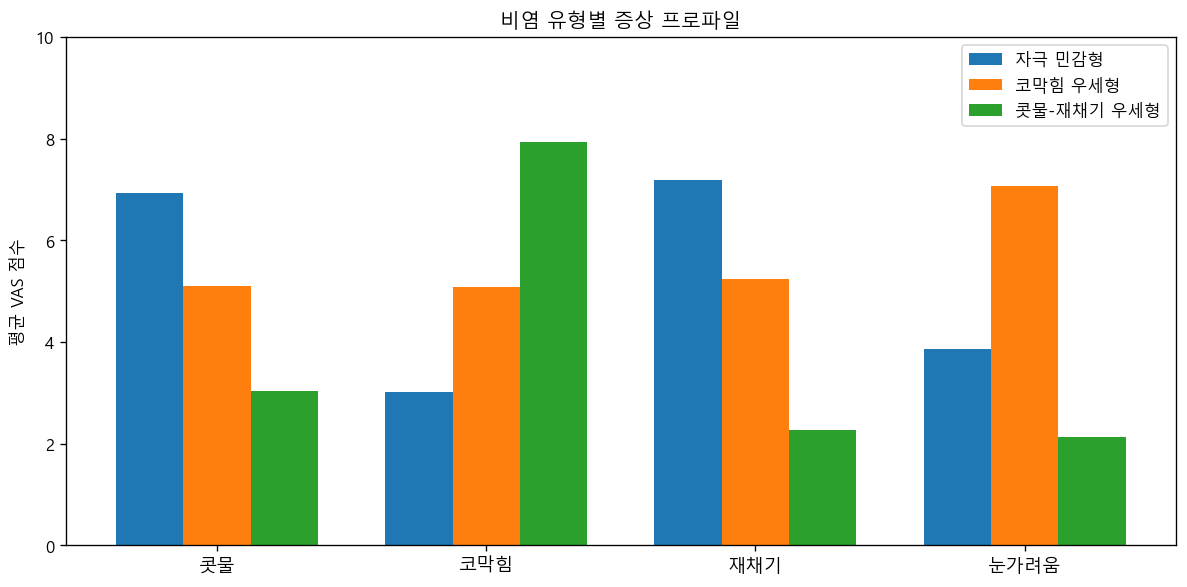

In [21]:
plot_cluster_profiles(
    df_clustered,
    features=VAS_FEATURES,
    save_path='../outputs/figures/06_cluster_profiles.png'
)

## 5. 클러스터별 통계 요약

In [22]:
summary = df_clustered.groupby('cluster_label')[VAS_FEATURES].agg(['mean', 'std']).round(2)
summary.columns = ['_'.join(col) for col in summary.columns]
print('=== 클러스터별 증상 통계 ===')
summary

=== 클러스터별 증상 통계 ===


,nasal_discharge_mean,nasal_discharge_std,nasal_congestion_mean,nasal_congestion_std,sneezing_mean,sneezing_std,eye_itching_mean,eye_itching_std
cluster_label,,,,,,,,
자극 민감형,6.93,1.13,3.03,1.49,7.18,1.29,3.86,1.21
코막힘 우세형,5.11,1.54,5.09,1.38,5.24,1.76,7.07,1.16
콧물-재채기 우세형,3.04,1.47,7.92,1.04,2.27,1.10,2.14,1.03


## 6. 새 사용자 유형 예측 테스트

In [23]:
from src.models.clustering import predict_cluster

# 테스트: 콧물·재채기가 심한 사용자
test_user = {
    'nasal_discharge': 8,
    'nasal_congestion': 2,
    'sneezing': 9,
    'eye_itching': 4,
}

predicted_type = predict_cluster('../outputs/models/kmeans_rhinitis.pkl', test_user)
print(f'예측 비염 유형: {predicted_type}')

예측 비염 유형: 자극 민감형
